**Кейс. Вы работаете дата-сайентистом в компании Booking. Одна из проблем компании — это нечестные отели, которые накручивают себе рейтинг. Одним из способов обнаружения таких отелей является построение модели, которая предсказывает рейтинг отеля. Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель ведёт себя нечестно, и его стоит проверить**

Импортируем необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns
import statistics

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

Читаем данные и выводим информацию

In [2]:
hotel_data = pd.read_csv('hotels.csv', sep=',')
display(hotel_data.head(5))

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [3]:
#Делаем копию датасета, чтобы его не повредить и  не изменить
data=hotel_data.copy()
#Проверяем
#display(data.head())

Задаем уровень значимости

In [4]:
import scipy.stats as stats
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


In [5]:
#Загружаем основную информацию о датасете
display(data.info())
print('В датасете: {} записей'.format(data.shape[0]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

None

В датасете: 386803 записей


Выясним сколько дубликатов в данных и удалим эти данные

In [6]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))
#Задаем условие, согласно которому если есть дубликаты, их необходимо удалить
if data[data.duplicated()].shape[0]==0:
    print('В представленном датасете нет дубликатов')
else:
# Удаляем дубликаты:
     data = data.drop_duplicates()
     print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Количество дубликатов: 307
Размер таблицы после удаления дубликатов: (386496, 17)


*Задание 4.2 Сколько отелей представлено в наборе данных?*

Приведем свдения о дате обзора к типу данных "datetime"

In [7]:
data['review_date'] = pd.to_datetime(data['review_date'])

*Задание 4.3 Когда был оставлен самый свежий отзыв? Когда был оставлен самый первый отзыв? Введите ответ в формате yyyy-mm-dd.*

In [8]:
display(data['review_date'].max())
display(data['review_date'].min())

Timestamp('2017-08-03 00:00:00')

Timestamp('2015-08-04 00:00:00')

*Задание 4.4. Сколько уникальных тегов представлено в наборе данных?*

In [9]:
data_tags=data.copy()
data_tags['tags'] = data_tags['tags'].apply(lambda x: x[3:-3].split(" ', ' "))
tags_1 = list(data_tags['tags'].explode().value_counts())
len(tags_1)

2368

*Задание 4.5. Какой тег представлен в наибольшем числе отзывов?*

In [13]:
display(data_tags.describe(include=['object']))

,hotel_address,hotel_name,reviewer_nationality,negative_review,positive_review,tags,days_since_review
count,386496,386496,386496,386496,386496,386496,386496
unique,1493,1492,225,248828,311737,47135,731
top,163 Marsh Wall Docklands Tower Hamlets London ...,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,No Positive,"[Leisure trip, Couple, Double Room, Stayed 1 n...",1 days
freq,3587,3587,183952,95833,26863,3853,1910


*Задание 4.6. Из тегов выясните, на сколько ночей чаще всего останавливаются путешественники в отелях.*

Создадим новый признак "stay" - продолжительность пребывания

In [10]:
regex = '\d{1}' # регулярное выражение для нахождения чисел
data_tags['stay'] = data['tags'].str.findall(regex).str.get(0)
display(data_tags['stay'].value_counts())

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_14528\2949821289.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  regex = '\d{1}' # регулярное выражение для нахождения чисел


stay
1    148245
2    107356
3     68251
4     33331
5     14543
6      6910
7      5056
8      1770
9       888
Name: count, dtype: int64

Выведем на экран все названия столбцов с пропусками

In [11]:
cols_null_percent = data_tags.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

lat     0.633383
lng     0.633383
stay    0.037775
dtype: float64

In [12]:
#display(data_tags.info())

Убираем пропуски, заменяя значения медианой для признаков широта и долга и 1, для признака продолжительность остановки в отеле, так как мы выяснили, что это самая популярная продолжительность остановки.

In [13]:
fill_data = data_tags.copy()
values = {
    'lat': fill_data['lat'].median(),
    'lng': fill_data['lng'].median(),
    'stay': fill_data['stay']==1}
#заполняем пропуски в соответствии с заявленным словарем
fill_data = fill_data.fillna(values)

#Выведем основную информацию и убедимся что в данных нет пропусков
fill_data.isnull().mean()

hotel_address                                 0.0
additional_number_of_scoring                  0.0
review_date                                   0.0
average_score                                 0.0
hotel_name                                    0.0
reviewer_nationality                          0.0
negative_review                               0.0
review_total_negative_word_counts             0.0
total_number_of_reviews                       0.0
positive_review                               0.0
review_total_positive_word_counts             0.0
total_number_of_reviews_reviewer_has_given    0.0
reviewer_score                                0.0
tags                                          0.0
days_since_review                             0.0
lat                                           0.0
lng                                           0.0
stay                                          0.0
dtype: float64

Поменяем тип данных признака "stay" на числовой, так как сейчас он текстовый

In [14]:
fill_data['stay']=fill_data['stay'].astype('int64')

Точные сведения о дате нас не интерисуют, а вот время года и год в полне могут пригодиться. Получим новые признаки из даты

In [15]:
fill_data['Year'] = fill_data['review_date'].dt.year
fill_data['quarter'] = fill_data['review_date'].dt.quarter

In [16]:
display(fill_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 20 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               386496 non-null  object        
 1   additional_number_of_scoring                386496 non-null  int64         
 2   review_date                                 386496 non-null  datetime64[ns]
 3   average_score                               386496 non-null  float64       
 4   hotel_name                                  386496 non-null  object        
 5   reviewer_nationality                        386496 non-null  object        
 6   negative_review                             386496 non-null  object        
 7   review_total_negative_word_counts           386496 non-null  int64         
 8   total_number_of_reviews                     386496 non-null  int64         
 9 

None

In [17]:
#Удаляем неинформативные признаки
drop_data = fill_data.drop(['hotel_address', 'review_date', 'hotel_name', 'tags', 'days_since_review', 'negative_review' , 'positive_review'], axis=1)

выведем основную информацию о столбцах

In [18]:
display(drop_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 13 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386496 non-null  int64  
 1   average_score                               386496 non-null  float64
 2   reviewer_nationality                        386496 non-null  object 
 3   review_total_negative_word_counts           386496 non-null  int64  
 4   total_number_of_reviews                     386496 non-null  int64  
 5   review_total_positive_word_counts           386496 non-null  int64  
 6   total_number_of_reviews_reviewer_has_given  386496 non-null  int64  
 7   reviewer_score                              386496 non-null  float64
 8   lat                                         386496 non-null  float64
 9   lng                                         386496 non-null  float64
 10  s

None

Закодируем признак "reviewer_nationality"

In [19]:
import category_encoders as ce # импорт для работы с кодировщиком
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(drop_data['reviewer_nationality'])
drop_data_new = pd.concat([drop_data, type_bin], axis=1)

Удалим последний текстовый признак

In [20]:
#Удаляем неинформативные признаки
Data_EDA = drop_data_new.drop(['reviewer_nationality'], axis=1)

Посмотрим уникальные значения признаков

Для признаков долгота и ширирота большое количество уникальны даннх, так как данные признаки имеют значения в несколько знаков после запятой.
Округлим данные до 1 знака, этого для анализа достаточно

In [21]:
#Определяем функцию для перевода данных столба в строки
def list_del(l):
    elem=round(l,1)
    return elem

#Применяем функицию и фзаменям списки строками
Data_EDA['lng']=Data_EDA['lng'].apply(list_del)
Data_EDA['lat']=Data_EDA['lat'].apply(list_del)
#display(Data_EDA.head(1))

Посмотрим основную информацию о признаках

In [22]:
# создаём пустой список
unique_list_data = []
# пробегаемся по именам столбцов в таблице
for col in Data_EDA.columns:
    # создаём кортеж (имя столбца, число уникальных значений)
    item = (col, Data_EDA[col].nunique(), Data_EDA[col].dtypes, Data_EDA[col].min()) 
    # добавляем кортеж в список
    unique_list_data.append(item) 
# создаём вспомогательную таблицу и сортируем её
unique_counts_data = pd.DataFrame(
    unique_list_data,
    columns=['Column_Name', 'Num_Unique', 'Type', 'min']
).sort_values(by='Num_Unique',  ignore_index=True)
# выводим её на экран
display(unique_counts_data)

,Column_Name,Num_Unique,Type,min
0,reviewer_nationality_0,2,int64,0.0
1,reviewer_nationality_1,2,int64,0.0
2,reviewer_nationality_2,2,int64,0.0
3,reviewer_nationality_3,2,int64,0.0
4,reviewer_nationality_7,2,int64,0.0
5,reviewer_nationality_6,2,int64,0.0
6,reviewer_nationality_5,2,int64,0.0
7,reviewer_nationality_4,2,int64,0.0
8,Year,3,int32,2015.0
9,quarter,4,int32,1.0


Теперь разделим все признаки по типу, перечислим их:

Примем, что если значений более 150 - то это непрерывный признак, остальные категориальные

In [23]:
# создаём пустой список для непрервных признаков
num_list = []
# создаём пустой список для категориальных признаков
cat_list = []


# пробегаемся по именам столбцов в таблице
for col in Data_EDA.columns:
    if Data_EDA[col].nunique() > 150:
        num_list.append(col)
    else:
        cat_list.append(col)

display(num_list)
display(cat_list)

['additional_number_of_scoring',
 'review_total_negative_word_counts',
 'total_number_of_reviews',
 'review_total_positive_word_counts',
 'total_number_of_reviews_reviewer_has_given']

['average_score',
 'reviewer_score',
 'lat',
 'lng',
 'stay',
 'Year',
 'quarter',
 'reviewer_nationality_0',
 'reviewer_nationality_1',
 'reviewer_nationality_2',
 'reviewer_nationality_3',
 'reviewer_nationality_4',
 'reviewer_nationality_5',
 'reviewer_nationality_6',
 'reviewer_nationality_7']

Оценка значимости категориальных признаков.
Для оценки значимости категориальных переменных будем использовать изученный нами непараметрический тест хи-квадрат, реализованный в библиотеке sklearn.feature_selection.chi2. Метод возвращает массив значений хи-квадрат и p-value для каждого признака. Используем только значения хи-квадрат и выведем их на графике

In [24]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = Data_EDA.drop(['reviewer_score'], axis = 1)  
y = Data_EDA['reviewer_score'] 

Из списка категориальных признаков необходимо исключить признак 'reviewer_score' и признак 'lng', так как первый признак - целевая переменная, а второй имеет отрицательные значения

In [25]:
cat_lis_up = ['average_score',
 'lat',
 'stay',
 'Year',
 'quarter',
 'reviewer_nationality_0',
 'reviewer_nationality_1',
 'reviewer_nationality_2',
 'reviewer_nationality_3',
 'reviewer_nationality_4',
 'reviewer_nationality_5',
 'reviewer_nationality_6',
 'reviewer_nationality_7']

Для оценки значимости категориальных переменных будем использовать изученный нами непараметрический тест хи-квадрат, реализованный в библиотеке sklearn.feature_selection.chi2. Метод возвращает массив значений хи-квадрат и p-value для каждого признака. Используем только значения хи-квадрат и выведем их на графике:

<Axes: >

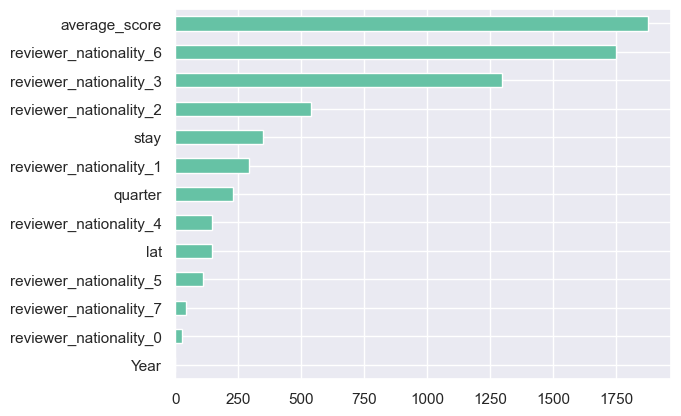

In [26]:
y=y.astype('int')

...
from sklearn.feature_selection import chi2 # хи-квадрат

imp_cat = pd.Series(chi2(X[cat_lis_up], y)[0], index=cat_lis_up)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh')

Для оценки значимости непрерывных переменных будем использовать функцию f_classif из библиотеки sklearn. В основе метода оценки значимости переменных лежит изученный вами в юнитах по статистике анализ (ANOVA). Основу процедуры составляет обобщение результатов двух выборочных t-тестов для независимых выборок (2-sample t).

<Axes: >

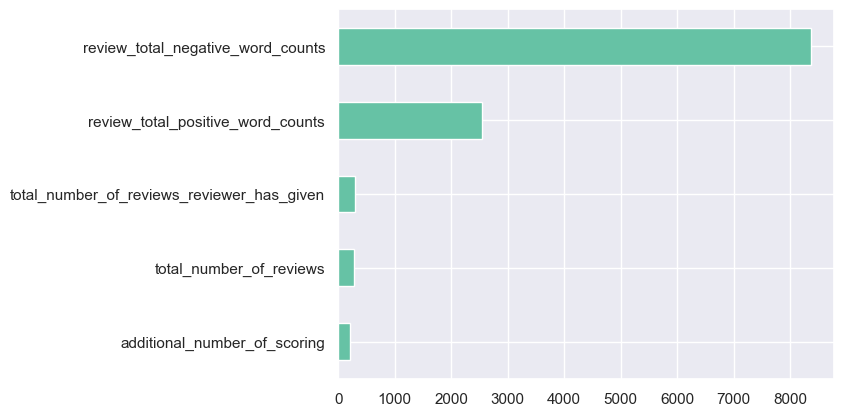

In [27]:
from sklearn.feature_selection import f_classif # anova

imp_num = pd.Series(f_classif(X[num_list], y)[0], index = num_list)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

Удаляем незначимые признаки

In [52]:
data_drope_all=Data_EDA.drop(['Year', 'additional_number_of_scoring', 'total_number_of_reviews', 'total_number_of_reviews_reviewer_has_given', 'lng'], axis=1)

#display(data_drope_all.info())

In [53]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = data_drope_all.drop(['reviewer_score'], axis = 1)  
y = data_drope_all['reviewer_score'] 

In [54]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [55]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [56]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  

In [57]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.14005123140577166
